In [1]:
from py_files.setup import *
setup_notebook()

# $\phi$-argument

**Goal:** Show empirics that support faling $\phi$, even as I cannot estimate this econometrically.

In [2]:
# 1. solve Leontif
years = range(1975, 2025)
df_we = we.compute_wage_employment_timeseries(years, kappa=0.6)

Fetching compensation (NABP36) ...
Fetching hours (NABB36) ...
Fetching employees (NABB36) ...
Processing year 1975...
  1975: w_I/w_C=0.868  L_I/L_C=1.094
Processing year 1976...
  1976: w_I/w_C=0.885  L_I/L_C=1.086
Processing year 1977...
  1977: w_I/w_C=0.864  L_I/L_C=1.054
Processing year 1978...
  1978: w_I/w_C=0.865  L_I/L_C=1.056
Processing year 1979...
  1979: w_I/w_C=0.895  L_I/L_C=1.038
Processing year 1980...
  1980: w_I/w_C=0.924  L_I/L_C=0.978
Processing year 1981...
  1981: w_I/w_C=0.943  L_I/L_C=0.855
Processing year 1982...
  1982: w_I/w_C=0.910  L_I/L_C=0.803
Processing year 1983...
  1983: w_I/w_C=0.938  L_I/L_C=0.813
Processing year 1984...
  1984: w_I/w_C=0.937  L_I/L_C=0.851
Processing year 1985...
  1985: w_I/w_C=0.972  L_I/L_C=0.863
Processing year 1986...
  1986: w_I/w_C=0.999  L_I/L_C=0.905
Processing year 1987...
  1987: w_I/w_C=0.994  L_I/L_C=0.901
Processing year 1988...
  1988: w_I/w_C=0.988  L_I/L_C=0.883
Processing year 1989...
  1989: w_I/w_C=0.989  L_I/

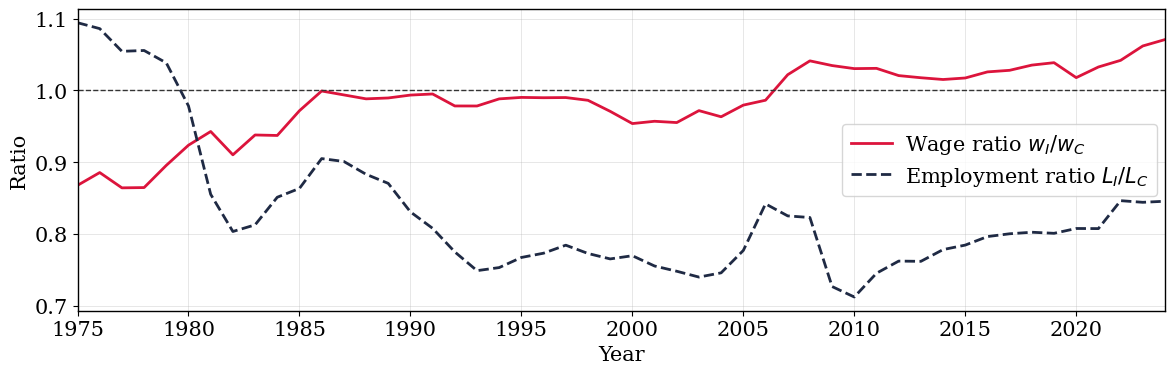

(<Figure size 1200x400 with 1 Axes>, <Axes: xlabel='Year', ylabel='Ratio'>)

In [6]:
# 2. plot
we.plot_wage_employment(df_we)

Outcome evidence v. mechanism evidence:
1. The above is outcome evidence.
2. I need some mechanism evidence also: 

    FORSK01 gives R&D wages abot total R&D costs, which are rising for the most technical firms.

# Mechanism evidence

For industry $i$ in year $t there are 9 educational groups, $e$. Each $e$ has an employment count, then the Herfindahl concentration index is per industry is,
$$
    H_{i,t} = \sum_{e=1}^9 \left[\frac{ L_{i,e,t} }{\sum_{e'} L_{i,e',t}} \right]^2
$$
Then per the Leontif inverse continous aggregation, the sectoral concentration indices are,
$$
    H_{I,t} \sum_{i=1}^{39} w_{I,t} H_{i,t}, \quad H_{C,t} \sum_{i=1}^{39} w_{C,t} H_{i,t}
$$
The following code, fetches educational data per the 39-grouping, computes the Herfindahl index perindustry and aggregates like done on $LS_i$:

In [4]:
df

NameError: name 'df' is not defined

In [ ]:
# ========== ========== ========== ========== ========== ==========
# 1. fetch
RAS310 = DstApi('RAS310')
edu = [
    'H10','H20','H30','H35','H40','H50','H60','H70','H80']

params = {
    'table':  'RAS310',
    'format': 'BULK',
    'lang':   'en',
    'variables': [
        {'code': 'OMRÅDE',      'values': ['000']}, # all DK
        {'code': 'UDDANNELSE',  'values': edu},   # educational groups
        {'code': 'BRANCHE07',   'values': ['*']},   # all
        {'code': 'ALDER',       'values': ['TOT']}, # all
        {'code': 'KØN',         'values': ['TOT']}, # all
        {'code': 'Tid',         'values': ['*']},   # all
    ]
}

df = RAS310.get_data(params=params)
df['INDHOLD'] = pd.to_numeric(df['INDHOLD'], errors='coerce')

# ========== ========== ========== ========== ========== ==========
# 2. format
df['branche_code'] = (
        df['BRANCHE07'].astype(str)
        .str.extract(r'^\s*([^ ]+)', expand=False))

# 3. drop 'TOT' and 'x'
df = df[~df['branche_code'].isin(['TOT','X'])]
df['year'] = df['TID'].astype(int)
df = df[['year','UDDANNELSE','branche_code','INDHOLD']].copy()

# ========== ========== ========== ========== ========== ==========
# 3. Compute direct IO weighted education shares by sector
results = []
for year in df['year'].unique():
    year_result = il.compute_direct_for_year(year)

    out_req = year_result['output_requirements']
    out_C = out_req['C'] + out_req['G']
    out_I = out_req['I'].copy()
    
    w_C = out_C / out_C.sum()
    w_I = out_I / out_I.sum()
    
    # Aggregate sub-industry weights to 36a2 parent codes
    parent_codes = pd.Series({s: var_groups.sub_to_parent.get(s, s) for s in w_C.index})
    w_C_36a2 = w_C.groupby(parent_codes).sum()
    w_I_36a2 = w_I.groupby(parent_codes).sum()
    
    df_year = df[df['year'] == year].copy()
    
    # For each education group, compute weighted employment in I and C
    row = {'year': year}
    for edu_code, edu_group in df_year.groupby('UDDANNELSE'):
        emp = edu_group.set_index('branche_code')['INDHOLD']
        
        common_C = w_C_36a2.index.intersection(emp.index)
        common_I = w_I_36a2.index.intersection(emp.index)
        
        row[f'{edu_code}_I'] = (w_I_36a2[common_I] * emp[common_I]).sum()
        row[f'{edu_code}_C'] = (w_C_36a2[common_C] * emp[common_C]).sum()
    
    results.append(row)

edu_sectoral = pd.DataFrame(results).set_index('year')

# ========== ========== ========== ========== ========== ==========
# 4. Compute education shares within each sector
edu_codes = [c.replace('_I','') for c in edu_sectoral.columns if c.endswith('_I')]

total_I = sum(edu_sectoral[f'{e}_I'] for e in edu_codes)
total_C = sum(edu_sectoral[f'{e}_C'] for e in edu_codes)

shares = pd.DataFrame(index=edu_sectoral.index)
for e in edu_codes:
    shares[f'{e}_I_share'] = edu_sectoral[f'{e}_I'] / total_I
    shares[f'{e}_C_share'] = edu_sectoral[f'{e}_C'] / total_C